# Scylla Benchmarks

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import json
import re
import csv
from dataclasses import dataclass
from pathlib import Path

In [2]:
frinx = "Scylla"

def savefig(fig, name):
    out = (Path("graphs") / name).with_suffix(".pdf")
    fig.savefig(out, bbox_inches="tight")

## Fragging on Nym: Latency between fragments

In [3]:
testbed_path = Path("../nym-testbed")
outputs_path = testbed_path / "shadow" / "outputs"

@dataclass
class Frag:
    sender: str
    chance: str
    run: int
    latency_ms: float

    def column(self):
        return int(self.chance[2]) - 1

def load_shadow_output_file(path: Path) -> [Frag]:
    frags = []
    match = re.match("chance_(...)_seed_(.)", path.stem)
    if match is None:
        return []
    chance = match.group(1)
    run = int(match.group(2))

    with path.open() as fobj:
        for line in fobj:
            match = re.search('\\(sent by (\\w+)\\) is complete.+ (\\d+) milliseconds', line)
            if match is None:
                continue
            sender = match.group(1)
            latency = int(match.group(2))
            frag = Frag(sender=sender, chance=chance, run=run, latency_ms=latency)
            frags.append(frag)
    return frags

def load_shadow_output_files(path: Path) -> [Frag]:
    result = []
    for name in path.iterdir():
        result.extend(load_shadow_output_file(name))
    return result

frags = load_shadow_output_files(outputs_path)

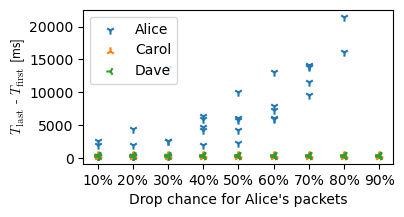

In [4]:
def plot_drop_chance_vs_latency(ax):
    res_alice = [f for f in frags if f.sender == "alice"]
    x, y = [], []
    for frag in res_alice:
        x.append(frag.column())
        y.append(frag.latency_ms)
    ax.scatter(x, y, marker="1", label="Alice")

    res_carol = [f for f in frags if f.sender == "eve"]
    x, y = [], []
    for frag in res_carol:
        x.append(frag.column())
        y.append(frag.latency_ms)
    ax.scatter(x, y, marker="2", label="Carol")

    res_dave = [f for f in frags if f.sender == "someone"]
    x, y = [], []
    for frag in res_dave:
        x.append(frag.column())
        y.append(frag.latency_ms)
    ax.scatter(x, y, marker="3", label="Dave")

    ax.legend()
    ax.set_xticks(
        [0, 1, 2, 3, 4, 5, 6, 7, 8],
        [f"{x * 10}%" for x in range(1, 10)],
    )
    ax.set_xlabel("Drop chance for Alice's packets")
    ax.set_ylabel("\\(T_\\mathrm{last}\\) - \\(T_\\mathrm{first}\\) [ms]", usetex=True)

fig, ax = plt.subplots(figsize=(4, 2))
plot_drop_chance_vs_latency(ax)
savefig(fig, "drop_chance_vs_latency")

## Computation time

In [5]:
@dataclass
class Result:
    name: str
    mean: float

    @property
    def mean_ms(self):
        return self.mean / 1000000

    @property
    def mean_mus(self):
        return self.mean / 1000

    def matches(self, regex):
        return re.match(regex, self.name)

    @staticmethod
    def load_json(path):
        meta = json.loads((path / "new" / "benchmark.json").read_text())
        estimates = json.loads((path / "new" / "estimates.json").read_text())
        result = Result(name=meta["group_id"], mean=estimates["mean"]["point_estimate"])
        return result

def load_frinx_results(path: Path) -> [Result]:
    results = []
    for bench in path.iterdir():
        if (bench / "new").exists():
            result = Result.load_json(bench)
            results.append(result)
    return results

def load_sphinx_results(path: Path) -> [Result]:
    results = []
    for folder in path.iterdir():
        if m := re.match('length_(\\d+)', folder.name):
            length = int(m.group(1))
            for inner in folder.iterdir():
                if (inner / "new").exists():
                    result = Result.load_json(inner)
                    result.name = f"{result.name} ({length})"
                    results.append(result)
    return results

In [6]:
frinx_results = load_frinx_results(Path("scylla/target/criterion"))
sphinx_results = load_sphinx_results(Path("sphinx-benchmarks/target/criterion"))

### Creation times

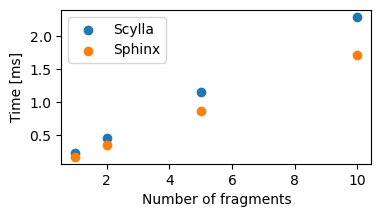

In [7]:
def plot_fragment_count_vs_creation_time(ax):
    payload_size = 128
    path_length = 3

    xs = []
    ys = []

    for result in frinx_results:
        if match := result.matches(f"Scylla::create_onions\\({path_length}, {payload_size}, (\\d+)\\)"):
            xs.append(int(match.group(1)))
            ys.append(result.mean_ms)

    ax.scatter(xs, ys, label=frinx)

    ys = []

    for result in sphinx_results:
        if match := result.matches(f"sphinx creation \\({payload_size}\\) \\({path_length}\\)"):
            for x in xs:
                ys.append(x * result.mean_ms)

    ax.scatter(xs, ys, label="Sphinx")

    ax.set_xlabel("Number of fragments")
    ax.set_ylabel("Time [ms]")
    ax.legend()

fig, ax = plt.subplots(figsize=(4, 2))
plot_fragment_count_vs_creation_time(ax)
savefig(fig, "fragment_count_vs_creation_time")

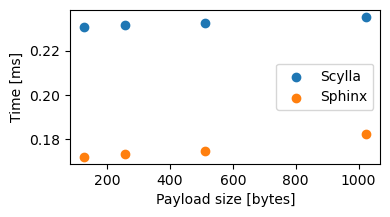

In [8]:
def plot_payload_size_vs_creation_time(ax):
    fragment_count = 1
    path_length = 3

    xs = []
    ys = []

    for result in frinx_results:
        if match := result.matches(f"Scylla::create_onions\\({path_length}, (\\d+), {fragment_count}\\)"):
            xs.append(int(match.group(1)))
            ys.append(result.mean_ms)

    ax.scatter(xs, ys, label=frinx)

    xs = []
    ys = []

    for result in sphinx_results:
        if match := result.matches(f"sphinx creation \\((\\d+)\\) \\({path_length}\\)"):
            xs.append(int(match.group(1)))
            ys.append(result.mean_ms)

    ax.scatter(xs, ys, label="Sphinx")

    ax.set_xlabel("Payload size [bytes]")
    ax.set_ylabel("Time [ms]")
    ax.legend()

fig, ax = plt.subplots(figsize=(4, 2))
plot_payload_size_vs_creation_time(ax)
savefig(fig, "payload_size_vs_creation_time")

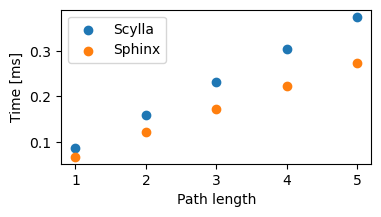

In [9]:
def plot_path_length_vs_creation_time(ax):
    fragment_count = 1
    payload_size = 128

    xs = []
    ys = []

    for result in frinx_results:
        if match := result.matches(f"Scylla::create_onions\\((\\d+), {payload_size}, {fragment_count}\\)"):
            xs.append(int(match.group(1)))
            ys.append(result.mean_ms)

    ax.scatter(xs, ys, label=frinx)

    xs = []
    ys = []

    for result in sphinx_results:
        if match := result.matches(f"sphinx creation \\({payload_size}\\) \\((\\d+)\\)"):
            xs.append(int(match.group(1)))
            ys.append(result.mean_ms)

    ax.scatter(xs, ys, label="Sphinx")

    ax.set_xlabel("Path length")
    ax.set_ylabel("Time [ms]")
    ax.legend()

fig, ax = plt.subplots(figsize=(4, 2))
plot_path_length_vs_creation_time(ax)
savefig(fig, "path_length_vs_creation_time")

### Processing time

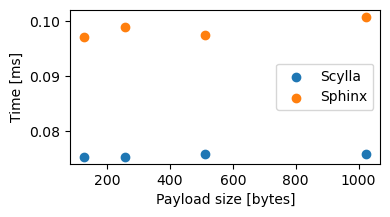

In [10]:
def plot_payload_size_vs_processing_time(ax):
    xs = []
    ys = []
    
    for result in frinx_results:
        if match := result.matches(f"Scylla::process\\(Flag::Relay, (\\d+)\\)"):
            xs.append(int(match.group(1)))
            ys.append(result.mean_ms)

    ax.scatter(xs, ys, label=frinx)

    xs = []
    ys = []
    
    for result in sphinx_results:
        if match := result.matches(f"sphinx unwrap \\((\\d+)\\) \\(3\\)"):
            xs.append(int(match.group(1)))
            ys.append(result.mean_ms)

    ax.scatter(xs, ys, label="Sphinx")
    ax.set_xlabel("Payload size [bytes]")
    ax.set_ylabel("Time [ms]")
    ax.legend()
    
fig, ax = plt.subplots(figsize=(4, 2))
plot_payload_size_vs_processing_time(ax)
savefig(fig, "payload_size_vs_processing_time")

In [11]:
def print_processing_times_fragment_deliver():
    for result in frinx_results:
        if match := result.matches(f"Scylla::process\\(Flag::(Deliver|Fragment), (\\d+)\\)"):
            print("{} {} bytes: {} ms".format(match.group(1), match.group(2), result.mean_ms))
            
print_processing_times_fragment_deliver()

Fragment 128 bytes: 0.03964538839349798 ms
Deliver 128 bytes: 0.03965432119193411 ms
Fragment 256 bytes: 0.03984512691149239 ms
Deliver 256 bytes: 0.039774293351178075 ms
Fragment 512 bytes: 0.04056202131999518 ms
Deliver 512 bytes: 0.04023306447312047 ms
Fragment 1024 bytes: 0.04033100903221699 ms
Deliver 1024 bytes: 0.04032611323001156 ms


### Reassembly time

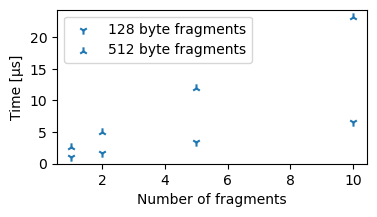

In [12]:
def plot_fragment_count_vs_reassembly_time(ax):
    payload_size = 128

    xs = []
    ys = []

    for result in frinx_results:
        if match := result.matches(f"Scylla::defrag\\({payload_size}, (\\d+)\\)"):
            xs.append(int(match.group(1)))
            ys.append(result.mean_mus)

    ax.scatter(xs, ys, label=f"{payload_size} byte fragments", marker="1")

    payload_size = 512

    xs = []
    ys = []

    for result in frinx_results:
        if match := result.matches(f"Scylla::defrag\\({payload_size}, (\\d+)\\)"):
            xs.append(int(match.group(1)))
            ys.append(result.mean_mus)

    ax.scatter(xs, ys, label=f"{payload_size} byte fragments", marker="2", color="tab:blue")

    ax.set_xlabel("Number of fragments")
    ax.set_ylabel("Time [μs]")

    ax.legend()

fig, ax = plt.subplots(figsize=(4, 2))
plot_fragment_count_vs_reassembly_time(ax)
savefig(fig, "fragment_count_vs_reassembly_time")

### SURB creation

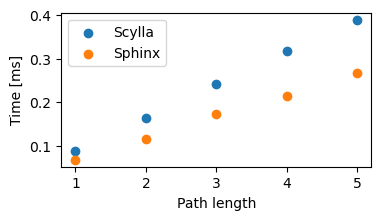

In [13]:
def plot_path_length_vs_surb_creation(ax):
    xs = []
    ys = []

    for result in frinx_results:
        if match := result.matches(f"Scylla::create_surb\\((\\d+)\\)"):
            xs.append(int(match.group(1)))
            ys.append(result.mean_ms)

    ax.scatter(xs, ys, label=frinx)

    xs = []
    ys = []

    for result in sphinx_results:
        if match := result.matches(f"sphinx surb \\((\\d+)\\)"):
            xs.append(int(match.group(1)))
            ys.append(result.mean_ms)

    ax.scatter(xs, ys, label="Sphinx")

    ax.set_xlabel("Path length")
    ax.set_ylabel("Time [ms]")

    ax.legend()

fig, ax = plt.subplots(figsize=(4, 2))
plot_path_length_vs_surb_creation(ax)
savefig(fig, "path_length_vs_surb_creation")

## Packet sizes

In [14]:
def int_values(obj):
    return {k: int(v) for k, v in obj.items()}

with open(Path("scylla") / "onion_sizes.csv", "r") as inf:
    frinx_sizes = [int_values(o) for o in csv.DictReader(inf)]
with open(Path("sphinx-benchmarks") / "sphinx_onion_sizes.csv", "r") as inf:
    sphinx_sizes = [int_values(o) for o in csv.DictReader(inf)]

def fil(l, **attrs):
    return [item for item in l if all(item[k] == v for k, v in attrs.items())]

def get(l, **attrs):
    res = fil(l, **attrs)
    if res:
        return res[0]
    return None

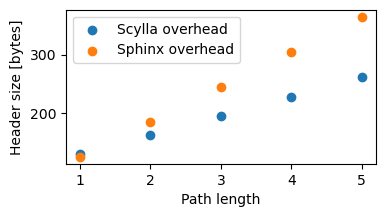

In [15]:
def plot_path_length_vs_onion_size(ax):
    xs = []
    ys = []

    for result in fil(frinx_sizes, fragment_count=1, payload_size=128):
        xs.append(result["path_length"])
        # add 48 bytes for OAEP, recipient and auth bytes
        ys.append(result["onion_size"] - 128 + 48)

    ax.scatter(xs, ys, label=f"{frinx} overhead")

    xs = []
    ys = []

    for result in fil(sphinx_sizes, payload_size=512):
        xs.append(result["path_length"])
        ys.append(result["onion_size"] - 512)

    ax.scatter(xs, ys, label="Sphinx overhead")

    ax.set_xlabel("Path length")
    ax.set_ylabel("Header size [bytes]")
    ax.legend()

fig, ax = plt.subplots(figsize=(4, 2))
plot_path_length_vs_onion_size(ax)
savefig(fig, "path_length_vs_onion_size")